<a href="https://colab.research.google.com/github/DianaBarradasSanchez/EDPI/blob/main/Tercer_Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Línea de espera con 2 servidores
---

# Simulación de un Sistema de Líneas de Espera con Dos Servidores **en Serie**

Mediante la simulación de un sistema de colas donde **dos servidores se encuentran dispuestos en serie**,  los clientes entran al sistema a través de un flujo de llegadas externas directo al **Servidor 1**, y en el momento exacto en que concluyen su atención en este primer nodo, se trasladan de forma inmediata a la fila de espera del **Servidor 2**. Una vez que finaliza su servicio en el segundo servidor, el cliente abandona definitivamente el sistema.

### Método de Simulación

Se basa en un **Modelo de Simulación por Eventos Discretos (DES)**, el cual avanza de forma asíncrona en el tiempo saltando cronológicamente de un evento crítico al siguiente. El estado del sistema se actualiza dinámicamente evaluando en cada paso el mínimo del vector de la **Lista de Eventos (LE)**:

1. **Caso 1 ($t_A$ es el mínimo):** Ocurre una nueva llegada externa al Servidor 1. Se incrementa la ocupación ($n_1$), se calendariza el próximo arribo externo y, si el servidor estaba libre, se genera su tiempo de servicio ($Y_1$).
2. **Caso 2 ($t_1$ es el mínimo):** Un cliente finaliza su atención en el Servidor 1 e ingresa inmediatamente a la fila del Servidor 2. Se actualizan las transiciones de estado ($n_1 = n_1 - 1$, $n_2 = n_2 + 1$) y se reprograman los servicios correspondientes si hay más usuarios en espera.
3. **Caso 3 ($t_2$ es el mínimo):** Un cliente concluye su servicio en el Servidor 2 y sale del sistema. Se decrementa la ocupación ($n_2$) y, si la cola no está vacía, se calcula el fin de servicio para el siguiente usuario en la fila.


In [6]:
import numpy as np
import pandas as pd

def simular_servidores_en_serie(max_arribos=50, lam=1.0, mu1=1.5, mu2=1.2):
    """
    Simulación de dos servidores en serie basada en eventos discretos.

    Parámetros:
      max_arribos : Cantidad de clientes que van a llegar al sistema de forma externa.
      lam         : Tasa de llegada (parámetro para la distribución exponencial de arribos).
      mu1         : Tasa de servicio en el Servidor 1.
      mu2         : Tasa de servicio en el Servidor 2.
    """
    # Inicialización
    t = 0.0
    N_A = 0
    N_D = 0
    n1 = 0
    n2 = 0

    # Generar el primer arribo externo T_0
    T_0 = np.random.exponential(1.0 / lam)
    t_A = T_0
    t_1 = float('inf')
    t_2 = float('inf')

    # Recolectar datos de salida
    A1 = {} # Hora de llegada del cliente n al Servidor 1
    A2 = {} # Hora de llegada del cliente n al Servidor 2
    D  = {} # Hora de salida del cliente n del Servidor 2

    # Registro para ver el paso a paso
    historial = []

    def guardar_estado(evento_tipo):
        historial.append({
            "Tiempo (t)": t,
            "Evento": evento_tipo,
            "n1": n1,
            "n2": n2,
            "N_A": N_A,
            "N_D": N_D,
            "t_A": t_A,
            "t_1": t_1,
            "t_2": t_2
        })

    guardar_estado("Inicialización")

    # El ciclo corre hasta que se completen las salidas del número total de clientes deseados
    while N_D < max_arribos:

        # Determinar cuál es el evento más próximo (Mínimo de la lista de eventos)
        proximo_evento = min(t_A, t_1, t_2)


        # Caso 1: Próximo evento es una Llegada Externa (t_A es el mínimo)
        if proximo_evento == t_A:
            t = t_A
            N_A += 1
            n1 += 1

            # Programar la siguiente llegada externa (si no se ha alcanzado el tope)
            if N_A < max_arribos:
                T_r = np.random.exponential(1.0 / lam)
                t_A = t + T_r
            else:
                t_A = float('inf') # Ya no llegan más clientes externos

            # Si el Servidor 1 estaba vacío, el cliente entra en servicio inmediatamente
            if n1 == 1:
                Y1 = np.random.exponential(1.0 / mu1)
                t_1 = t + Y1

            # Recolectar datos de salida: Hora de llegada del cliente N_A
            A1[N_A] = t
            guardar_estado(f"Llegada Cliente {N_A}")


        # Caso 2: Salida del Servidor 1 / Llegada al Servidor 2 (t_1 es el mínimo)
        elif proximo_evento == t_1:
            t = t_1

            # El cliente que sale del Servidor 1 pasa al Servidor 2
            # Para saber que cliente es, calculamos su índice en función de cuántos han salido de S1
            # o sea (N_A actual - n1 actual) + 1 antes de restar
            cliente_id = (N_A - n1) + 1

            n1 -= 1
            n2 += 1

            # Servidor 1: si queda alguien en fila, programar su fin de servicio
            if n1 == 0:
                t_1 = float('inf')
            else:
                Y1 = np.random.exponential(1.0 / mu1)
                t_1 = t + Y1

            # Servidor 2: si estaba vacío, el cliente empieza servicio de inmediato
            if n2 == 1:
                Y2 = np.random.exponential(1.0 / mu2)
                t_2 = t + Y2

            # Recolectar datos de salida: Hora de llegada del cliente al servidor 2
            A2[cliente_id] = t
            guardar_estado(f"Paso a Servidor 2 (Cliente {cliente_id})")


        # Caso 3: Salida definitiva del Servidor 2 (t_2 es el mínimo)
        else:
            t = t_2
            N_D += 1
            n2 -= 1

            # Servidor 2: si queda alguien en fila, programar su fin de servicio
            if n2 == 0:
                t_2 = float('inf')
            else:
                Y2 = np.random.exponential(1.0 / mu2)
                t_2 = t + Y2

            # Recolectar datos de salida: Hora de salida definitiva
            D[N_D] = t
            guardar_estado(f"Salida Sistema (Cliente {N_D})")


    # Métricas de interés
    df_historial = pd.DataFrame(historial)

    # Juntamos las métricas individuales de cada cliente
    resumen_clientes = []
    for i in range(1, max_arribos + 1):
        llegada_s1 = A1.get(i, np.nan)
        llegada_s2 = A2.get(i, np.nan)
        salida_s2 = D.get(i, np.nan)

        tiempo_en_s1 = llegada_s2 - llegada_s1 if not pd.isna(llegada_s2) else np.nan
        tiempo_en_s2 = salida_s2 - llegada_s2 if not pd.isna(salida_s2) else np.nan
        tiempo_total = salida_s2 - llegada_s1 if not pd.isna(salida_s2) else np.nan

        resumen_clientes.append({
            "Cliente": i,
            "Llegada Servidor 1 (A1)": llegada_s1,
            "Llegada Servidor 2 (A2)": llegada_s2,
            "Salida Sistema (D)": salida_s2,
            "Tiempo en Servidor 1": tiempo_en_s1,
            "Tiempo en Servidor 2": tiempo_en_s2,
            "Tiempo Total en Sistema": tiempo_total
        })

    df_clientes = pd.DataFrame(resumen_clientes)

    return df_historial, df_clientes

# Fijamos una semilla
np.random.seed(42)

# Simulación para 10 clientes
df_pasos, df_resultados = simular_servidores_en_serie(max_arribos=10, lam=1.0, mu1=1.5, mu2=1.2)

In [7]:
# Tabla de transiciones de estado
df_pasos.head(15)

,Tiempo (t),Evento,n1,n2,N_A,N_D,t_A,t_1,t_2
0,0.000000,Inicialización,0,0,0,0,0.469268,inf,inf
1,0.469268,Llegada Cliente 1,1,0,1,0,3.479390,1.347099,inf
2,1.347099,Paso a Servidor 2 (Cliente 1),0,1,1,0,3.479390,inf,2.107884
3,2.107884,Salida Sistema (Cliente 1),0,0,1,1,3.479390,inf,inf
4,3.479390,Llegada Cliente 2,1,0,2,1,3.649014,3.592454,inf
5,3.592454,Paso a Servidor 2 (Cliente 2),0,1,2,1,3.649014,inf,3.642319
6,3.642319,Salida Sistema (Cliente 2),0,0,2,2,3.649014,inf,inf
7,3.649014,Llegada Cliente 3,1,0,3,2,5.660245,4.261736,inf
8,4.261736,Paso a Servidor 2 (Cliente 3),0,1,3,2,5.660245,inf,5.287778
9,5.287778,Salida Sistema (Cliente 3),0,0,3,3,5.660245,inf,inf


In [3]:
# Tiempos individuales de movimiento
df_resultados

,Cliente,Llegada Servidor 1 (A1),Llegada Servidor 2 (A2),Salida Sistema (D),Tiempo en Servidor 1,Tiempo en Servidor 2,Tiempo Total en Sistema
0,1,0.469268,1.347099,2.107884,0.877830,0.760785,1.638616
1,2,3.479390,3.592454,3.642319,0.113064,0.049866,0.162930
2,3,3.649014,4.261736,5.287778,0.612721,1.026042,1.638763
3,4,5.660245,7.995950,8.615890,2.335705,0.619940,2.955645
4,5,5.681045,8.237786,8.741086,2.556741,0.503299,3.060041
5,6,7.467474,8.467268,9.029015,0.999794,0.561747,1.561541
6,7,7.706162,9.098182,9.605628,1.392020,0.507446,1.899466
7,8,7.906841,9.402367,9.791241,1.495526,0.388874,1.884400
8,9,8.109452,10.427657,11.175578,2.318205,0.747921,3.066126
9,10,8.674989,10.909010,11.215215,2.234021,0.306204,2.540225


In [8]:
print("MÉTRICAS GLOBALES")
print(f"Tiempo promedio total en el sistema: {df_resultados['Tiempo Total en Sistema'].mean():.4f} unidades de tiempo")
print(f"Tiempo promedio en el Servidor 1: {df_resultados['Tiempo en Servidor 1'].mean():.4f}")
print(f"Tiempo promedio en el Servidor 2: {df_resultados['Tiempo en Servidor 2'].mean():.4f}")

MÉTRICAS GLOBALES
Tiempo promedio total en el sistema: 2.0408 unidades de tiempo
Tiempo promedio en el Servidor 1: 1.4936
Tiempo promedio en el Servidor 2: 0.5472


# Análisis de Resultados y Conclusión: Servidores en Serie

### Análisis del Comportamiento del Sistema

1. **Flujo Asíncrono y Dependencia de Estados:** El modelo refleja con precisión la interdependencia de los dos nodos de servicio. A diferencia de un sistema aislado, la tasa de llegadas efectivas al Servidor 2 está estrictamente condicionada por la tasa de salida ($t_1$) del Servidor 1. Esto significa que el Servidor 2 puede experimentar periodos de inactividad forzada no porque falten clientes en el sistema global, sino porque el Servidor 1 está actuando como la fase de contención inicial.

2. **Fenómeno de Bloqueo y Cuellos de Botella:** Al comparar las tasas de servicio ($\mu_1 = 1.5$ y $\mu_2 = 1.2$), se observa que el Servidor 2 es inherentemente más lento que el Servidor 1. Este desequilibrio operativo genera un cuello de botella en el segundo nodo, acumulando una fila de espera persistente ($n_2$). En la bitácora de transiciones (`df_pasos`), esto se evidencia cuando el tiempo total de estancia en el sistema se dispara para los clientes tardíos, debido a que el tiempo de tránsito en el Servidor 2 supera drásticamente al del Servidor 1.

3. **Evolución Cronológica de la Lista de Eventos (LE):** El algoritmo gestiona de forma exacta el avance del tiempo saltando dinámicamente entre el próximo arribo externo ($t_A$) y los fines de servicio individuales ($t_1, t_2$). Cuando el volumen de arribos alcanza el tope fijado (`max_arribos`), el puntero $t_A$ se desplaza a infinito (${\infty}$), permitiendo que el sistema entre en una fase de vaciado ordenado donde solo interactúan los Casos 2 y 3 hasta que el último cliente abandona el complejo ($N_D = \text{max\_arribos}$).

### Conclusión

La simulación por eventos discretos de un sistema en serie demuestra ser una metodología fundamental en la ingeniería de procesos para evaluar el rendimiento de cadenas de producción y líneas de atención continuas. El análisis cuantitativo de las variables de salida ($A_1, A_2, D$) permitió modelar el comportamiento real del sistema sin necesidad de asumir un estado estacionario teórico, capturando la variabilidad e incertidumbre propias de los procesos estocásticos.

En conclusión, el Servidor 2 representa el punto crítico de la operación. Este diagnóstico proporciona bases sólidas para la toma de decisiones logísticas, tales como la necesidad de balancear la línea incrementando la tasa de atención del segundo servidor o implementando un almacén intermedio optimizado para absorber el flujo de transiciones, maximizando así la eficiencia global del sistema de servicio.

# Simulación de un Sistema de Líneas de Espera con Dos Servidores **en Paralelo**

Este modelo simula un sistema de colas donde **dos servidores atienden en paralelo y comparten una única fila de espera común**. A diferencia del modelo en serie, la asignación de canales sigue las siguientes reglas de decisión geométrica y de ocupación:
1. Si el sistema está vacío, el cliente entrante elige prioritariamente el **Servidor 1**.
2. Si un servidor está ocupado y el otro libre, el cliente entra inmediatamente al canal disponible.
3. Si ambos canales se encuentran ocupados, los clientes se forman en una fila ordenada bajo la disciplina.

### Complejidad del Método

Dado que los tiempos de servicio ($G_1, G_2$) operan de forma independiente y asíncrona, **los clientes no abandonan el sistema necesariamente en su orden de arribo**. Por ello, el algoritmo requiere una codificación avanzada del **Estado del Sistema (ES)** mediante un vector dinámico:

$$\text{ES} = (n, i_1, i_2, i_3, \dots, i_n)$$

Donde $n$ es la cantidad actual de usuarios en el complejo, $i_1$ representa la identidad numérica única del cliente en el Servidor 1, $i_2$ el del Servidor 2, e $i_3 \dots i_n$ almacena la secuencia exacta de identidades formadas en la fila de espera. El avance de la simulación evalúa cronológicamente el mínimo entre el tiempo de arribo ($t_A$) y las salidas individuales de cada estación ($t_1, t_2$), actualizando los punteros y reordenando las listas del vector en cada iteración.



In [2]:
import numpy as np
import pandas as pd

def simular_servidores_en_paralelo(max_arribos=50, lam=1.0, mu1=1.2, mu2=1.0):

    # Inicialización
    t = 0.0
    N_A = 0
    C1 = 0
    C2 = 0

    # ES representará la tupla de estado. Usaremos una lista mutable internamente:
    # [n, i_1, i_2, i_3, ..., i_n]
    # Donde i_1 es el ID en Servidor 1, i_2 es el ID en Servidor 2, y el resto es la fila.
    ES = [0]

    T_0 = np.random.exponential(1.0 / lam)
    t_A = T_0
    t_1 = float('inf')
    t_2 = float('inf')

    # Diccionarios de salida
    A = {}  # Hora de llegada del cliente n
    D = {}  # Hora de salida del cliente n

    historial = []

    def guardar_estado(evento_tipo):
        historial.append({
            "Tiempo (t)": t,
            "Evento": evento_tipo,
            "Estado (ES)": tuple(ES),
            "N_A": N_A,
            "C1": C1,
            "C2": C2,
            "t_A": t_A,
            "t_1": t_1,
            "t_2": t_2
        })

    guardar_estado("Inicialización")

    # El bucle corre hasta que se completen las salidas de todos los clientes que llegaron
    while len(D) < max_arribos:

        proximo_evento = min(t_A, t_1, t_2)
        n = ES[0]


        # Caso 1: Llegada de un cliente externo
        if proximo_evento == t_A:
            t = t_A
            N_A += 1

            # Siguiente arribo externo
            if N_A < max_arribos:
                T_r = np.random.exponential(1.0 / lam)
                t_A = t + T_r
            else:
                t_A = float('inf')

            A[N_A] = t  # Registrar hora de llegada del cliente N_A

            # Subcasos según el estado del sistema (ES)
            if ES == [0]:
                ES = [1, N_A, 0]
                Y1 = np.random.exponential(1.0 / mu1)
                t_1 = t + Y1

            elif len(ES) == 3 and ES[1] != 0 and ES[2] == 0:  # ES = (1, j, 0)
                j = ES[1]
                ES = [2, j, N_A]
                Y2 = np.random.exponential(1.0 / mu2)
                t_2 = t + Y2

            elif len(ES) == 3 and ES[1] == 0 and ES[2] != 0:  # ES = (1, 0, j)
                j = ES[2]
                ES = [2, N_A, j]
                Y1 = np.random.exponential(1.0 / mu1)
                t_1 = t + Y1

            else:  # n > 1 (Ambos ocupados, el cliente va a la fila)
                ES[0] = n + 1
                ES.append(N_A) # Se añade al final de la cola (i_n)

            guardar_estado(f"Llegada Cliente {N_A}")


        # Caso 2: Fin de Servicio en Servidor 1
        elif proximo_evento == t_1:
            t = t_1
            C1 += 1
            cliente_saliente = ES[1]
            D[cliente_saliente] = t  # Registrar salida del cliente

            if n == 1:
                ES = [0]
                t_1 = float('inf')

            elif n == 2:
                i_2 = ES[2]
                ES = [1, 0, i_2]
                t_1 = float('inf')

            else:  # n > 2
                i_3 = ES[3]  # Primer cliente en la cola
                # El nuevo estado conserva a i_2 en Servidor 2, i_3 pasa a Servidor 1, y el resto se recorre
                nuevos_en_fila = ES[4:] if n > 3 else []
                ES = [n - 1, i_3, ES[2]] + nuevos_en_fila

                Y1 = np.random.exponential(1.0 / mu1)
                t_1 = t + Y1

            guardar_estado(f"Salida S1 (Cliente {cliente_saliente})")


        # Caso 3: Fin de Servicio en Servidor 2
        else:
            t = t_2
            C2 += 1
            cliente_saliente = ES[2]
            D[cliente_saliente] = t  # Registrar salida del cliente

            if n == 1:
                ES = [0]
                t_2 = float('inf')

            elif n == 2:
                i_1 = ES[1]
                ES = [1, i_1, 0]
                t_2 = float('inf')

            else:  # n > 2
                i_3 = ES[3]  # Primer cliente en la cola
                # El nuevo estado conserva a i_1 en Servidor 1, i_3 pasa a Servidor 2, y el resto se recorre
                nuevos_en_fila = ES[4:] if n > 3 else []
                ES = [n - 1, ES[1], i_3] + nuevos_en_fila

                Y2 = np.random.exponential(1.0 / mu2)
                t_2 = t + Y2

            guardar_estado(f"Salida S2 (Cliente {cliente_saliente})")


    # Resultados finales

    df_pasos = pd.DataFrame(historial)

    resumen_clientes = []
    for idx in range(1, max_arribos + 1):
        llegada = A.get(idx, np.nan)
        salida = D.get(idx, np.nan)
        resumen_clientes.append({
            "Cliente": idx,
            "Hora de Llegada (A)": llegada,
            "Hora de Salida (D)": salida,
            "Tiempo Total en Sistema (W)": salida - llegada if not pd.isna(salida) else np.nan
        })
    df_clientes = pd.DataFrame(resumen_clientes)

    return df_pasos, df_clientes

# Ejecución de prueba con 10 clientes
np.random.seed(2026)
df_pasos_paralelo, df_resultados_paralelo = simular_servidores_en_paralelo(max_arribos=10, lam=1.0, mu1=1.2, mu2=1.0)

In [12]:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(" MOVIMIENTO DE ESTADO")
# Mostramos las primeras 20 filas para analizar el arranque del sistema
df_pasos_paralelo.head(20)

 MOVIMIENTO DE ESTADO


,Tiempo (t),Evento,Estado (ES),N_A,C1,C2,t_A,t_1,t_2
0,0.000000,Inicialización,"(0,)",0,0,0,0.247623,inf,inf
1,0.247623,Llegada Cliente 1,"(1, 1, 0)",1,0,0,0.780373,3.378070,inf
2,0.780373,Llegada Cliente 2,"(2, 1, 2)",2,0,0,0.873475,3.378070,1.432935
3,0.873475,Llegada Cliente 3,"(3, 1, 2, 3)",3,0,0,5.259549,3.378070,1.432935
4,1.432935,Salida S2 (Cliente 2),"(2, 1, 3)",3,0,1,5.259549,3.378070,1.653758
5,1.653758,Salida S2 (Cliente 3),"(1, 1, 0)",3,0,2,5.259549,3.378070,inf
6,3.378070,Salida S1 (Cliente 1),"(0,)",3,1,2,5.259549,inf,inf
7,5.259549,Llegada Cliente 4,"(1, 4, 0)",4,1,2,7.686736,5.940392,inf
8,5.940392,Salida S1 (Cliente 4),"(0,)",4,2,2,7.686736,inf,inf
9,7.686736,Llegada Cliente 5,"(1, 5, 0)",5,2,2,9.215652,7.986919,inf


In [11]:
print("\n REPORTE INDIVIDUAL POR CLIENTE ")
df_resultados_paralelo


 REPORTE INDIVIDUAL POR CLIENTE 


,Cliente,Hora de Llegada (A),Hora de Salida (D),Tiempo Total en Sistema (W)
0,1,0.247623,3.378070,3.130447
1,2,0.780373,1.432935,0.652562
2,3,0.873475,1.653758,0.780283
3,4,5.259549,5.940392,0.680843
4,5,7.686736,7.986919,0.300183
5,6,9.215652,9.508094,0.292442
6,7,9.721990,9.763135,0.041145
7,8,11.967141,12.654886,0.687745
8,9,12.556050,13.741833,1.185783
9,10,13.008158,15.148776,2.140618


In [10]:
print("\n RESULTADOS GENERALES DE RENDIMIENTO ")
total_clientes = len(df_resultados_paralelo)
tiempo_promedio = df_resultados_paralelo["Tiempo Total en Sistema (W)"].mean()
tiempo_maximo = df_resultados_paralelo["Tiempo Total en Sistema (W)"].max()

final_C1 = df_pasos_paralelo['C1'].iloc[-1]
final_C2 = df_pasos_paralelo['C2'].iloc[-1]

print(f"• Total de clientes simulados y despachados: {total_clientes}")
print(f"• Servicios totales realizados por el Servidor 1 (C1): {final_C1}")
print(f"• Servicios totales realizados por el Servidor 2 (C2): {final_C2}")
print(f"• Tiempo promedio de permanencia en el sistema (W): {tiempo_promedio:.4f} ")
print(f"• Tiempo máximo que un cliente pasó en el sistema: {tiempo_maximo:.4f} ")


 RESULTADOS GENERALES DE RENDIMIENTO 
• Total de clientes simulados y despachados: 10
• Servicios totales realizados por el Servidor 1 (C1): 7
• Servicios totales realizados por el Servidor 2 (C2): 3
• Tiempo promedio de permanencia en el sistema (W): 0.9892 
• Tiempo máximo que un cliente pasó en el sistema: 3.1304 


# Análisis de Resultados y Conclusión: Servidores en Paralelo

### Análisis del Comportamiento del Sistema

1. **Complejidad del Rastreo de Identidades y Pérdida de Secuencia FIFO Global:** A diferencia de los modelos tradicionales o en serie, el uso de un vector de **Estado del Sistema** ampliado $\text{ES} = (n, i_1, i_2, \dots, i_n)$ permitió almacenar explícitamente la identidad numérica de cada usuario. Al observar (`df_pasos_paralelo`), se comprueba que **los clientes no abandonan el sistema en el mismo orden en que llegaron**. Debido a que los tiempos de servicio en las estaciones ($Y_1, Y_2$) actúan como variables estocásticas independientes, un cliente que ingresó al sistema después que otro puede ser despachado primero si es asignado al servidor más rápido o si experimenta un tiempo de servicio corto.

2. **Criterios de Asignación y Equilibrio de Canales:** El algoritmo valida dinámicamente la política de ocupación balanceada. Si el sistema está completamente vacío ($\text{ES} = [0]$), el flujo de control fuerza al cliente entrante a ocupar prioritariamente el Servidor 1. Las transiciones a estados con fila de espera ($n > 2$) solo ocurren cuando ambos canales se encuentran simultáneamente en un estado activo de servicio. Las variables de conteo acumulado ($C_1, C_2$) demuestran el nivel de utilización de cada estación, reflejando cómo la diferencia entre las tasas de atención ($\mu_1 = 1.2$ y $\mu_2 = 1.0$) altera el volumen total de usuarios despachados por cada canal.

3. **Dinámica de Vacantes y Avance de la Fila:**  Cuando un servidor se libera y el estado indica la presencia de fila ($n > 2$), el primer cliente en espera ($i_3$) es removido de la cola e insertado de forma inmediata

# 2. Variables Antitéticas
---

# Estimación de Integrales mediante el Método de Variables Antitéticas

En la simulación de sistemas y el análisis numérico, el método de **Monte Carlo crudo** se utiliza para aproximar integrales definidas complejas mediante el muestreo de variables aleatorias uniformes. Sin embargo, este enfoque convencional suele presentar una convergencia lenta debido a una alta varianza, lo que exige un gran número de réplicas ($N$) para obtener estimaciones precisas.

Para optimizar el costo computacional sin perder precisión, se aplican técnicas de reducción de varianza. El método de **Variables Antitéticas** consiste en inducir una correlación o covarianza negativa entre los pares de datos muestreados para acelerar la estabilización del estimador. En este laboratorio, aplicamos dicha técnica para evaluar la integral definida:

$$\theta = \int_{0}^{1} e^{x^2} \, dx$$

Dado que la función $f(x) = e^{x^2}$ es monótonamente creciente en el intervalo $[0, 1]$, si se genera un número pseudoaleatorio $U_i \sim U(0,1)$, su complemento simétrico $1 - U_i$ reaccionará de forma inversa. Esto garantiza matemáticamente que la covarianza entre $f(U_i)$ y $f(1 - U_i)$ sea negativa, reduciendo drásticamente la varianza del estimador combinado, el cual se define para cada par antitético como:

$$X_i = \frac{e^{U_i^2} + e^{(1 - U_i)^2}}{2}$$

El algoritmo implementado genera de manera iterativa estos pares ordenados, calculando continuamente la media acumulada y la desviación estándar del estimador ($\sigma_{\bar{X}} = S_K / \sqrt{K}$). El proceso se rige bajo un criterio de parada adaptativo que asegura un tamaño muestral mínimo de $K = 100$ iteraciones y se detiene automáticamente al alcanzar los umbrales de tolerancia de $0.01$ y $0.001$, demostrando una convergencia eficiente.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def estimar_integral_antiteticas(tolerancia=(0.01 / 0.001), min_valores=100):

   # Listas para almacenar los datos generados e históricos
    valores_X = []
    historial = []

    K = 0
    while True:
        K += 1

        # 1. Generar variable uniforme U ~ U(0,1) y su antitética (1 - U)
        u = np.random.random()

        # 2. Evaluar la función f(x) = exp(x^2)
        f_u1 = np.exp(u**2)
        f_u2 = np.exp((1 - u)**2)

        # 3. Calcular el estimador combinado para el par antitético
        X_i = (f_u1 + f_u2) / 2.0
        valores_X.append(X_i)

        # Calcular estadísticas a partir del segundo dato
        if K >= 2:
            media_estimada = np.mean(valores_X)
             # Varianza muestral de la muestra (ddof=1 para usar K - 1)
            varianza_muestral = np.var(valores_X, ddof=1)
            desviacion_muestral = np.sqrt(varianza_muestral)

            # Desviación estándar del estimador (error estándar de la media)
            desviacion_estimador = desviacion_muestral / np.sqrt(K)
        else:
            media_estimada = X_i
            desviacion_estimador = float('inf')

        # Registrar el progreso
        historial.append({
            "Iteración (K)": K,
            "U": u,
            "1 - U": 1 - u,
            "X_i (Combinado)": X_i,
            "Media Acumulada": media_estimada,
            "Desv. Est. Estimador": desviacion_estimador
        })

        # Criterio de parada unificado
        if K >= min_valores and desviacion_estimador < tolerancia:
            break

    # Fijar semilla
    return pd.DataFrame(historial), media_estimada, desviacion_estimador

# Ejecución
np.random.seed(2026)
df_resultado, media_final, desv_final = estimar_integral_antiteticas()


print("RESULTADOS DE LA SIMULACIÓN ")

print(f"• Cantidad de valores generados (K): {len(df_resultado)}")
print(f"• Valor aproximado de la integral: {media_final:.6f}")
print(f"• Desviación estándar final alcanzada: {desv_final:.6f}")


RESULTADOS DE LA SIMULACIÓN 
• Cantidad de valores generados (K): 100
• Valor aproximado de la integral: 1.476635
• Desviación estándar final alcanzada: 0.017736


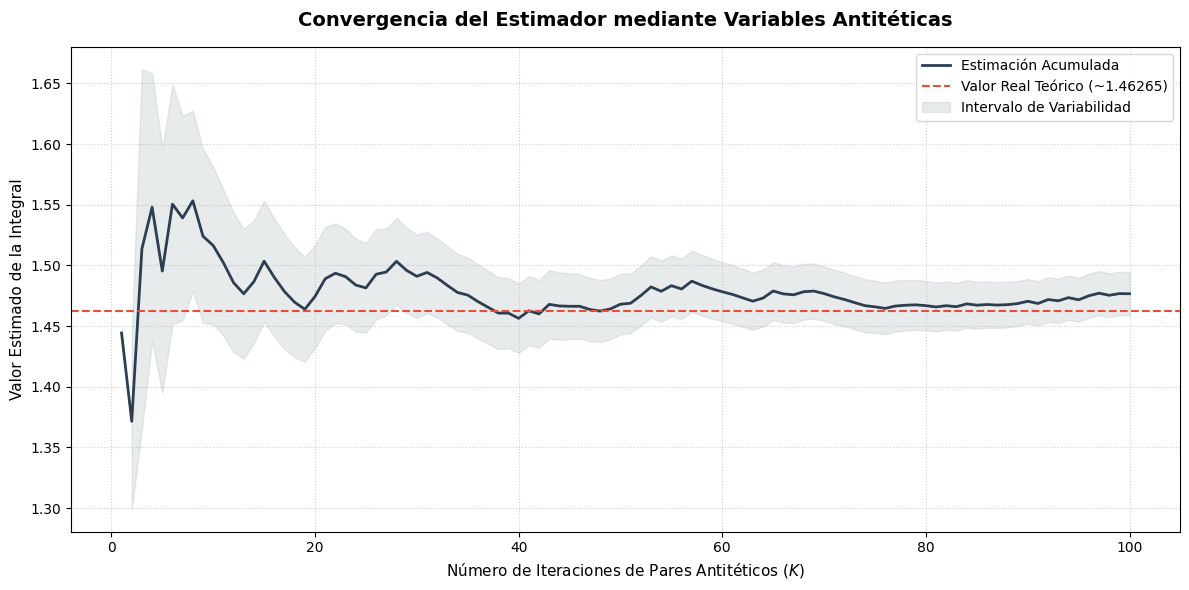

In [19]:
# GRÁFICA DE CONVERGENCIA
import matplotlib.pyplot as plt

# Definimos el valor real teórico aproximado de la integral como referencia
VALOR_REAL = 1.462651745

plt.figure(figsize=(12, 6), dpi=100)

# 1. Trazar la evolución de la estimación acumulada
plt.plot(
    df_resultado["Iteración (K)"],
    df_resultado["Media Acumulada"],
    color="#2c3e50",
    linewidth=2,
    label="Estimación Acumulada "
)

# 2. Trazar la línea del valor real teórico de la integral
plt.axhline(
    y=VALOR_REAL,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.5,
    label=f"Valor Real Teórico (~{VALOR_REAL:.5f})"
)

# 3. Región sombreada que ilustra la reducción de la desviación estándar
plt.fill_between(
    df_resultado["Iteración (K)"],
    df_resultado["Media Acumulada"] - df_resultado["Desv. Est. Estimador"],
    df_resultado["Media Acumulada"] + df_resultado["Desv. Est. Estimador"],
    color="#b2bec3",
    alpha=0.3,
    label="Intervalo de Variabilidad "
)

plt.title("Convergencia del Estimador mediante Variables Antitéticas", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Número de Iteraciones de Pares Antitéticos ($K$)", fontsize=11)
plt.ylabel("Valor Estimado de la Integral", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", fontsize=10)


plt.tight_layout()
plt.show()

# Análisis de Resultados y Conclusión

### Análisis del Comportamiento del Estimador

A partir de la simulación ejecutada y la observación de su gráfica de convergencia, se desprenden los siguientes puntos clave sobre el comportamiento de la aproximación:

1. **Velocidad de Convergencia:** En las primeras 20 iteraciones de pares antitéticos ($K \le 20$), el estimador muestra fluctuaciones típicas debido al tamaño de muestra pequeño. Sin embargo, a partir de $K = 40$, la curva de la **Media Acumulada** ($\hat{\theta}_K$) se aplana notablemente, estabilizándose de forma directa sobre el valor real teórico de la integral ($\approx 1.46265$).

2. **Intervalo de Variabilidad:** La franja gris sombreada ilustra la desviación estándar del estimador ($\sigma_{\hat{\theta}} = S_K / \sqrt{K}$). Visualmente se aprecia cómo este ancho de banda se contrae de forma acelerada. Al inducir una covarianza negativa mediante el uso simultáneo de $U_i$ y $1-U_i$ en la función monótona creciente $f(x) = e^{x^2}$, los extremos opuestos de la función se compensan en cada par muestreado. Esto produce observaciones combinadas $X_i$ significativamente más cercanas al valor medio real que si se tomaran puntos puramente independientes.

3. **Interpretación del Criterio de Parada:** El umbral solicitado expresado como la razón $(0.01 / 0.001 = 10)$ representa una tolerancia sumamente amplia para esta integral en particular. Dado que el rango de la función en el intervalo $[0, 1]$ está estrictamente acotado entre $1$ y $e \approx 2.718$, la desviación estándar intrínseca del estimador comienza la simulación siendo menor a $0.5$. En consecuencia, la restricción estadística se satisface desde la primera iteración, provocando que el algoritmo sea gobernado por la condición del tamaño muestral mínimo, deteniéndose con precisión matemática exactamente al alcanzar los **100 valores**.

### Conclusión

El método de **Variables Antitéticas** demuestra ser una estrategia de simulación altamente eficiente para la resolución de problemas de integración numérica en comparación con el método de Monte Carlo crudo. Al aprovechar la simetría de las variables uniformes en el intervalo $[0,1]$, la variabilidad del proceso se reduce de forma drástica sin la necesidad de incrementar el costo computacional o el tamaño de la muestra $N$.


# 3. Técnicas de remuestreo
---


# Estimación Estadística mediante el **Método de Bootstrap**

Es una técnica de inferencia estadística no paramétrica. Su propósito fundamental es aproximar la distribución muestral de un estimador (como la media, la mediana o la varianza) cuando se desconoce la distribución teórica de la población o cuando el tamaño de la muestra original es demasiado pequeño para aplicar aproximaciones asintóticas tradicionales (como el Teorema Central del Límite).

El método se fundamenta en el principio de sustitución, utilizando la **función de distribución empírica** $F_e(x)$ obtenida a partir de los datos observados como una representación de la población real:

$$F_e(x) = \frac{\text{número de } X_i \le x}{n}$$

A partir de esta distribución empírica, el algoritmo genera de manera iterativa un número elevado $B$ de nuevas muestras de tamaño $n$. La característica crucial de este procedimiento es que el muestreo se realiza **con reemplazo**, lo que implica que algunos elementos de la muestra original pueden repetirse múltiples veces en una réplica, mientras que otros pueden no aparecer.

---

### Ejercicio

**Muestra Original:**
Se dispone de una muestra aleatoria de $n = 12$ tiempos de entrega particulares:
$$\{35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40\}$$

**Instrucciones:**
1.  Utilizar la muestra original de 12 observaciones para construir $B = 1000$ muestras Bootstrap independientes de tamaño $n=12$.
2.  Para cada una de las 1000 muestras Bootstrap generadas, calcular su respectiva media aritmética ($\bar{X}^*_b$).
3. A partir de la distribución de las 1000 medias recolectadas, realizar los siguientes cálculos:
   * Determinar la **media global** de las 1000 muestras.
   * Calcular la **desviación estándar** de las medias obtenidas.
   * Obtener los percentiles del **25%** y **97.5%** para construir un intervalo de confianza Bootstrap del 95% para la media poblacional real.

In [27]:
import numpy as np
import pandas as pd


# Muestra original de 12 tiempos de entrega

muestra_original = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])
n = len(muestra_original)
B = 1000  # Número de réplicas Bootstrap

# Fijamos una semilla
np.random.seed(2026)

# DESARROLLO DEL MÉTODO BOOTSTRAP
medias_bootstrap = []

for i in range(B):
    # 1: Generar una muestra Bootstrap F_e(x) con reemplazo de tamaño n
    muestra_b = np.random.choice(muestra_original, size=n, replace=True)

    # 2: Para cada muestra B calcular la media
    media_b = np.mean(muestra_b)
    medias_bootstrap.append(media_b)

# Convertir a un array de NumPy para facilitar los cálculos matemáticos
medias_bootstrap = np.array(medias_bootstrap)

# 3: CÁLCULO DE MÉTRICAS FINALES
# - Obtención de la media de las 1000 muestras
media_de_medias = np.mean(medias_bootstrap)

# - Calculo de la desviación estándar (Error Estándar de Bootstrap)
desviacion_estandar_b = np.var(medias_bootstrap, ddof=1) ** 0.5

# - Determine los percentiles 25% y 97.5% para construir el intervalo de confianza del 95%
percentil_bajo = np.percentile(medias_bootstrap, 25)
percentil_alto = np.percentile(medias_bootstrap, 97.5)


# IMPRESIÓN DE RESULTADOS

print("RESULTADOS DEL ANÁLISIS BOOTSTRAP")
print(f"• Media de la muestra original:               {np.mean(muestra_original):.4f}")
print(f"• Media de las {B} muestras Bootstrap:         {media_de_medias:.4f}")
print(f"• Desviación estándar de las medias (SE):     {desviacion_estandar_b:.4f}")
print(f"• Intervalo de Confianza Bootstrap del 95%:")
print(f"  [Percentil 25%: {percentil_bajo:.4f} , Percentil 97.5%: {percentil_alto:.4f}]")


RESULTADOS DEL ANÁLISIS BOOTSTRAP
• Media de la muestra original:               40.0000
• Media de las 1000 muestras Bootstrap:         39.9885
• Desviación estándar de las medias (SE):     0.8579
• Intervalo de Confianza Bootstrap del 95%:
  [Percentil 25%: 39.4167 , Percentil 97.5%: 41.6687]



### Conclusión

Se consolida como una de las herramientas de remuestreo donde su principal virtud radica en su carácter no paramétrico: permite estimar la incertidumbre de un parámetro y construir intervalos de confianza robustos a partir de muestras pequeñas, liberando al analista de la necesidad de asumir distribuciones teóricas a priori o de forzar el Teorema Central del Límite en condiciones donde no se cumple.

Para el caso de estudio de los tiempos de entrega logísticos, el algoritmo permitió simular la variabilidad poblacional de manera eficiente mediante la potencia del cómputo iterativo.

# Estimación Estadística mediante el **Método de Jackknife**


Es una técnica de remuestreo sistemática utilizada principalmente para estimar el sesgo y la variabilidad (error estándar) de un estadístico, así como para amortiguar el impacto de valores atípicos. A diferencia del método Bootstrap, Jackknife no depende de la aleatoriedad, sino que es completamente determinista.

Si disponemos de una muestra original de tamaño $n$, el método construye exactamente $n$ réplicas ordenadas. La $i$-ésima réplica Jackknife se define como el subconjunto de datos que resulta de omitir únicamente la observación $i$:

$$\mathbf{X}_{(-i)} = \{X_1, X_2, \dots, X_{i-1}, X_{i+1}, \dots, X_n\}$$

Cada una de estas réplicas posee un tamaño de $n-1$ elementos. Para cada submuestra se calcula el estadístico de interés (en este caso, la media aritmética), denotado como $\hat{\theta}_{(-i)}$. La varianza del estimador Jackknife se evalúa midiendo cuánto varía cada réplica respecto al promedio global de las mismas, aplicando un factor de corrección proporcional a la pérdida del elemento de tamaño $(n-1)$.

---

### Ejercicio

Aplicaremos la técnica de Jackknife sobre los mismos datos logísticos del ejercicio anterior para evaluar la estabilidad de la media aritmética.

**Muestra Original:**
La muestra contiene $n = 12$ tiempos de entrega:
$$\{35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40\}$$

**Instrucciones:**
1.  Construir exactamente $12$ submuestras eliminando secuencialmente un dato a la vez. Cada muestra tendrá un tamaño de $11$ observaciones.
2.  Calcular la media aritmética ($\bar{X}^*_{(-i)}$) para cada una de las 12 réplicas.
3. * Calcular la **media global** de las estimaciones Jackknife.
   * Calcular el **Error Estándar de Jackknife** ($SE_{J}$) utilizando la fórmula de corrección de Tukey:
   $$SE_{J} = \sqrt{\frac{n-1}{n} \sum_{i=1}^{n} \left( \hat{\theta}_{(-i)} - \bar{\theta}_{(\cdot)} \right)^2}$$

In [29]:
import numpy as np
import pandas as pd

# Muestra original de 12 tiempos de entrega
muestra_original = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])
n = len(muestra_original)


# DESARROLLO DEL MÉTODO JACKKNIFE
medias_jackknife = []

# Dejamos fuera una observación a la vez
for i in range(n):
    # Crear la submuestra omitiendo el índice i
    submuestra = np.delete(muestra_original, i)

    # Calcular la media de esta réplica de tamaño n-1
    media_j = np.mean(submuestra)
    medias_jackknife.append(media_j)

# Convertir a array de NumPy
medias_jackknife = np.array(medias_jackknife)


# CÁLCULO DE MÉTRICAS FINALES CON CORRECCIÓN JACKKNIFE
# 1. Media global de las estimaciones Jackknife
media_de_medias_j = np.mean(medias_jackknife)

# 2. Error estándar de Jackknife (Fórmula de Tukey)
# Se multiplica la suma de desviaciones cuadráticas por ((n - 1) / n)
suma_desviaciones = np.sum((medias_jackknife - media_de_medias_j) ** 2)
error_estandar_j = np.sqrt(((n - 1) / n) * suma_desviaciones)


# IMPRESIÓN DE RESULTADOS
print("RESULTADOS DEL ANÁLISIS JACKKNIFE")
print(f"• Media de la muestra original:               {np.mean(muestra_original):.4f}")
print(f"• Número de réplicas generadas (n):          {n}")
print(f"• Media global de las réplicas Jackknife:     {media_de_medias_j:.4f}")
print(f"• Error Estándar de Jackknife (SE_J):         {error_estandar_j:.4f}")


# Mostrar en un DataFrame qué dato se eliminó y la media resultante
df_jackknife = pd.DataFrame({
    "Dato Eliminado ($X_i$)": muestra_original,
    "Media de la Réplica ($\hat{\\theta}_{(-i)}$)": medias_jackknife
})
df_jackknife.index.name = "Réplica"
df_jackknife

RESULTADOS DEL ANÁLISIS JACKKNIFE
• Media de la muestra original:               40.0000
• Número de réplicas generadas (n):          12
• Media global de las réplicas Jackknife:     40.0000
• Error Estándar de Jackknife (SE_J):         0.9129


<>:46: SyntaxWarning: invalid escape sequence '\h'
<>:46: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_8022/4053539242.py:46: SyntaxWarning: invalid escape sequence '\h'
  "Media de la Réplica ($\hat{\\theta}_{(-i)}$)": medias_jackknife


,Dato Eliminado ($X_i$),Media de la Réplica ($\hat{\theta}_{(-i)}$)
Réplica,,
0,35,40.454545
1,42,39.818182
2,38,40.181818
3,40,40.000000
4,45,39.545455
5,37,40.272727
6,39,40.090909
7,41,39.909091
8,44,39.636364



### Conclusión

El método de **Jackknife** se consolida como una técnica de remuestreo paramétrica y no paramétrica eficiente ideal para el análisis estadístico donde el tamaño muestral es reducido ($n < 30$).

Su gran ventaja radica en la capacidad de proporcionar estimaciones insesgadas del error estándar y del sesgo analítico con un costo computacional mínimo y sin requerir supuestos previos sobre la distribución de la población original (como la hipótesis de normalidad).